# 7-to-1 Magic State Distillation Results

Plots logical output error rate **P_out** vs. logical input infidelity **P_in** for
TG (transversal-gate) and LS (lattice-surgery) distillation protocols.

Theory: `P_out ≈ 7 · P_in³`  (first-order distillation, [[7,1,3]] code)

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

REPO   = Path(os.path.abspath('')).parent
TG_DIR = REPO / 'eval/logical_circuit_benchmark/distillation/tg_7to1'
LS_DIR = REPO / 'eval/logical_circuit_benchmark/distillation/ls_7to1'

MARKERS = ['o', 's', '^', 'D', 'v', 'P']
COLORS  = plt.rcParams['axes.prop_cycle'].by_key()['color']

def load_csv(path):
    path = Path(path)
    if not path.exists():
        print(f'  [skip] {path.name} not found')
        return pd.DataFrame()
    df = pd.read_csv(path)
    print(f'  Loaded {len(df):>4} rows  ←  {path.name}')
    return df

print('Loading TG results...')
tg_inj  = load_csv(TG_DIR / 'TG_injection_results.csv')
tg_full = load_csv(TG_DIR / 'TG_full_noise_results.csv')
tg_both = load_csv(TG_DIR / 'TG_both_results.csv')

print('Loading LS results...')
ls_inj  = load_csv(LS_DIR / 'LS_injection_results.csv')
ls_full = load_csv(LS_DIR / 'LS_full_noise_results.csv')
ls_both = load_csv(LS_DIR / 'LS_both_results.csv')

Loading TG results...
  Loaded    5 rows  ←  TG_injection_results.csv
  [skip] TG_full_noise_results.csv not found
  Loaded   26 rows  ←  TG_both_results.csv
Loading LS results...
  Loaded    5 rows  ←  LS_injection_results.csv
  [skip] LS_full_noise_results.csv not found
  Loaded   26 rows  ←  LS_both_results.csv


## Helpers

In [16]:
def get_pin_rows(df, p_filter=None):
    """Return rows with valid p_in (> 0), optionally filtered to a single p value."""
    if df.empty or 'p_in' not in df.columns:
        return pd.DataFrame()
    out = df[df['p_in'] > 0].copy()
    if p_filter is not None:
        out = out[np.isclose(out['p'], p_filter)]
    return out


def plot_pin_vs_ler(ax, df, group_col='d', p_filter=None,
                    label_prefix='', linestyle='-'):
    """Plot p_in vs ler_ps grouped by group_col. Returns True if any data plotted."""
    rows = get_pin_rows(df, p_filter)
    if rows.empty:
        return False
    for i, g in enumerate(sorted(rows[group_col].unique())):
        sub = rows[rows[group_col] == g].sort_values('p_in')
        ax.plot(sub['p_in'], sub['ler_ps'],
                marker=MARKERS[i % len(MARKERS)],
                color=COLORS[i % len(COLORS)],
                linestyle=linestyle,
                label=f'{label_prefix}d={g}', markersize=6)
    return True


def add_theory(ax):
    """Add 7·P_in³ theory line over the x-range spanned by existing plotted data.
    Reads x-data from already-plotted lines to avoid depending on axis limits
    before log scale is set."""
    xs = [x for line in ax.get_lines() for x in line.get_xdata()]
    if not xs:
        return
    xlo, xhi = min(xs), max(xs)
    p = np.logspace(np.log10(xlo), np.log10(xhi), 200)
    ax.plot(p, 7 * p**3, 'k--', lw=1.5, label=r'$7\,P_{\rm in}^3$', zorder=0)


def finalise_ax(ax, title='', xlabel=r'$P_{\rm in}$', ylabel=r'$P_{\rm out}$'):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    if title:
        ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8, framealpha=0.85)
    ax.grid(True, which='both', ls=':', alpha=0.4)

## 1. Injection-only noise  (`p = 0`)

Closest to the paper's plot: no background circuit noise, injection error only.  
Cubic suppression `P_out ≈ 7 P_in³` should be clearly visible.

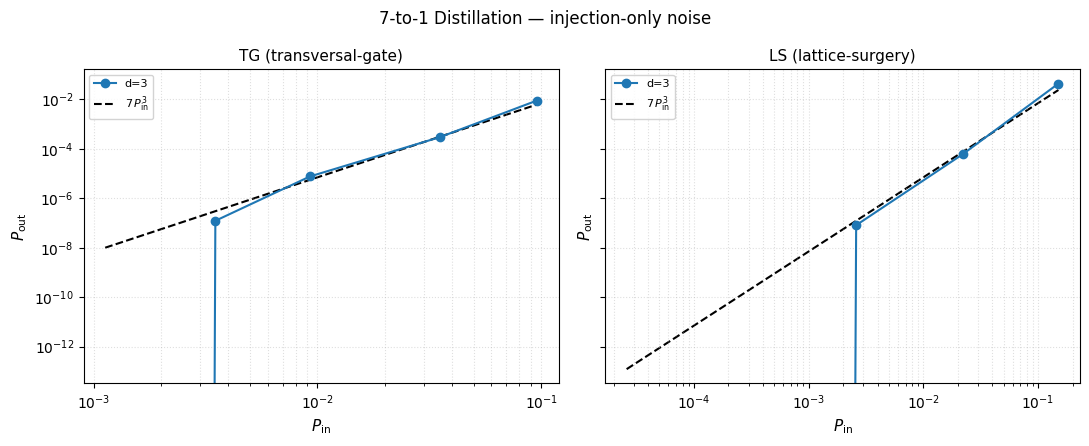

In [17]:
panels = [(tg_inj, 'TG (transversal-gate)'),
          (ls_inj, 'LS (lattice-surgery)')]
panels = [(df, t) for df, t in panels if not get_pin_rows(df).empty]

if not panels:
    print('No injection-only data yet. Run run_distillation_simulations.py --noise injection')
else:
    fig, axes = plt.subplots(1, len(panels), figsize=(5.5 * len(panels), 4.5),
                             sharey=len(panels) > 1)
    if len(panels) == 1:
        axes = [axes]
    fig.suptitle('7-to-1 Distillation — injection-only noise', fontsize=12)
    for ax, (df, title) in zip(axes, panels):
        plot_pin_vs_ler(ax, df, group_col='d')
        add_theory(ax)
        finalise_ax(ax, title=title)
    plt.tight_layout()
    plt.savefig(REPO / 'eval/distillation_injection.pdf', bbox_inches='tight')
    plt.show()

## 2. Both noise modes  (background `p` + injection `p_injected`)

One subplot per unique background noise level `p`.  
The noise floor imposed by background depolarizing is visible at small `P_in`.

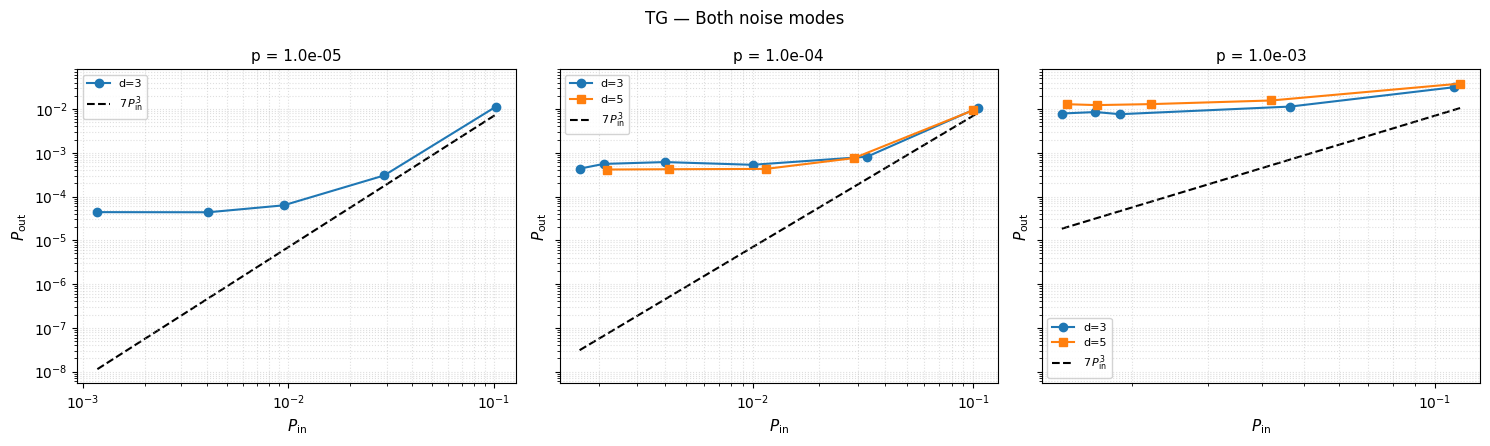

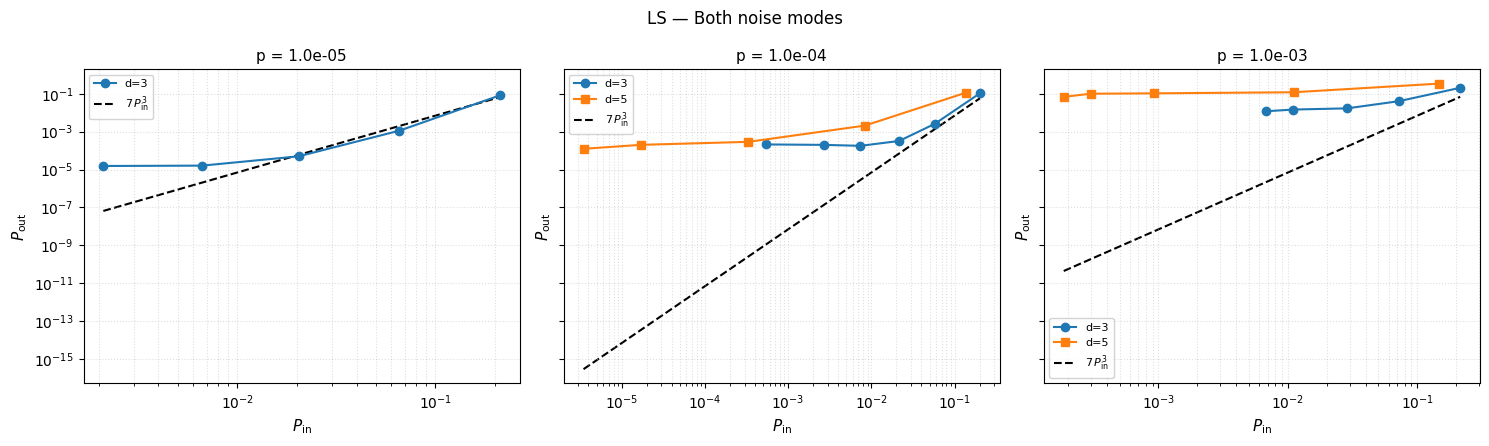

In [18]:
def plot_both_mode(df, title):
    rows = get_pin_rows(df)
    if rows.empty:
        print(f'{title}: no p_in data')
        return
    p_levels = sorted(rows['p'].unique())
    n = len(p_levels)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5),
                             sharey=n > 1, squeeze=False)
    fig.suptitle(title, fontsize=12)
    for ax, p_val in zip(axes[0], p_levels):
        plot_pin_vs_ler(ax, df, group_col='d', p_filter=p_val)
        add_theory(ax)
        finalise_ax(ax, title=f'p = {p_val:.1e}')
    plt.tight_layout()
    plt.show()

plot_both_mode(tg_both, 'TG — Both noise modes')
plot_both_mode(ls_both, 'LS — Both noise modes')

## 3. Full circuit-level noise  (sweep `p`, no injection)

In [19]:
panels = [(tg_full, 'TG'), (ls_full, 'LS')]
panels = [(df, t) for df, t in panels if not df.empty]

if not panels:
    print('No full-noise data yet.')
else:
    fig, axes = plt.subplots(1, len(panels), figsize=(5.5 * len(panels), 4.5),
                             sharey=len(panels) > 1, squeeze=False)
    fig.suptitle('7-to-1 Distillation — full circuit-level noise', fontsize=12)
    for ax, (df, title) in zip(axes[0], panels):
        for i, d in enumerate(sorted(df['d'].unique())):
            sub = df[df['d'] == d].sort_values('p')
            ax.plot(sub['p'], sub['ler_ps'],
                    marker=MARKERS[i % len(MARKERS)],
                    color=COLORS[i % len(COLORS)],
                    label=f'd={d}', markersize=6)
        finalise_ax(ax, title=title,
                    xlabel=r'Physical error rate $p$',
                    ylabel=r'$P_{\rm out}$')
    plt.tight_layout()
    plt.show()

No full-noise data yet.


## 4. TG vs LS comparison  (injection-only)

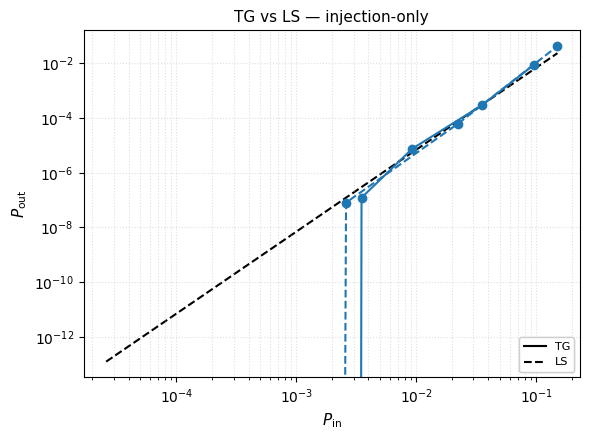

In [20]:
from matplotlib.lines import Line2D

tg_rows = get_pin_rows(tg_inj)
ls_rows = get_pin_rows(ls_inj)

if tg_rows.empty and ls_rows.empty:
    print('No injection-only data yet for either protocol.')
else:
    all_d = sorted(set(
        list(tg_rows['d'].unique() if not tg_rows.empty else []) +
        list(ls_rows['d'].unique() if not ls_rows.empty else [])
    ))
    fig, ax = plt.subplots(figsize=(6, 4.5))
    for i, d in enumerate(all_d):
        c, m = COLORS[i % len(COLORS)], MARKERS[i % len(MARKERS)]
        if not tg_rows.empty:
            sub = tg_rows[tg_rows['d'] == d].sort_values('p_in')
            ax.plot(sub['p_in'], sub['ler_ps'], marker=m, color=c,
                    ls='-',  label=f'TG d={d}', markersize=6)
        if not ls_rows.empty:
            sub = ls_rows[ls_rows['d'] == d].sort_values('p_in')
            ax.plot(sub['p_in'], sub['ler_ps'], marker=m, color=c,
                    ls='--', label=f'LS d={d}', markersize=6)
    add_theory(ax)
    finalise_ax(ax, title='TG vs LS — injection-only')
    h1, _ = ax.get_legend_handles_labels()
    ax.legend(fontsize=8, loc='upper left', framealpha=0.85)
    ax.add_artist(ax.legend(
        handles=[Line2D([0],[0], color='k', ls='-',  lw=1.5, label='TG'),
                 Line2D([0],[0], color='k', ls='--', lw=1.5, label='LS')],
        fontsize=8, loc='lower right', framealpha=0.85))
    plt.tight_layout()
    plt.savefig(REPO / 'eval/distillation_comparison.pdf', bbox_inches='tight')
    plt.show()

## 5. Data summary

In [21]:
for name, df in [('TG injection', tg_inj), ('TG full', tg_full), ('TG both', tg_both),
                 ('LS injection', ls_inj), ('LS full', ls_full), ('LS both', ls_both)]:
    if df.empty:
        print(f'{name:15s}  — no data')
        continue
    has_pin = 'p_in' in df.columns
    valid   = int((df['p_in'] > 0).sum()) if has_pin else 0
    ds      = sorted(df['d'].unique())
    ps      = sorted(df['p'].unique()) if 'p' in df.columns else []
    print(f'{name:15s}  rows={len(df):>4}  p_in={has_pin}  '
          f'pin_valid={valid:>4}  d={ds}  p={[f"{v:.0e}" for v in ps]}')

TG injection     rows=   5  p_in=True  pin_valid=   5  d=[np.int64(3)]  p=['0e+00']
TG full          — no data
TG both          rows=  26  p_in=True  pin_valid=  26  d=[np.int64(3), np.int64(5)]  p=['1e-05', '1e-04', '1e-03']
LS injection     rows=   5  p_in=True  pin_valid=   5  d=[np.int64(3)]  p=['0e+00']
LS full          — no data
LS both          rows=  26  p_in=True  pin_valid=  26  d=[np.int64(3), np.int64(5)]  p=['1e-05', '1e-04', '1e-03']
